In [24]:
# Uncommnent if you need to install the packages
# %pip install geopandas kagglehub
# update kagglehub to the latest version
# %pip install --upgrade kagglehub

# Load the dataset

Loading the extracted geopackage (.gpkg) of the extracted data using `wosis-data-selector` script without any filters except for 0-30cm depth.

In [25]:
import geopandas as gpd
# master file
wosis_raw = "Mexico_wosis_raw_merged.gpkg"
mexio_wosis_gdf = f"D:/tierra/datasets/raw/{wosis_raw}"
mexio_wosis_gdf = gpd.read_file(mexio_wosis_gdf)

#
print(f"Number of records in the raw WOSIS file: {len(mexio_wosis_gdf)}")
print(f"Number of unique profiles in the raw WOSIS file: {len(mexio_wosis_gdf['profile_id'].unique())}")
print(f"Number of columns in the raw WOSIS file: {len(mexio_wosis_gdf.columns)}")
print(f"List of columns in the raw WOSIS file: {list(mexio_wosis_gdf.columns)}")

mexio_wosis_gdf.head()

Number of records in the raw WOSIS file: 8102
Number of unique profiles in the raw WOSIS file: 6816
Number of columns in the raw WOSIS file: 34
List of columns in the raw WOSIS file: ['date', 'profile_id', 'longitude', 'latitude', 'upper_depth', 'lower_depth', 'country_name', 'bdfi33', 'bdfiod', 'bdwsod', 'cecph7', 'cfgr', 'cfvo', 'clay', 'ecec', 'elco20', 'elcosp', 'nitkjd', 'orgc', 'phaq', 'phca', 'phetb1', 'phkc', 'phnf', 'phprtn', 'sand', 'silt', 'tceq', 'totc', 'wg0006', 'wg0010', 'wg0033', 'wg0200', 'wg1500']


,date,profile_id,longitude,latitude,upper_depth,lower_depth,country_name,bdfi33,bdfiod,bdwsod,...,phprtn,sand,silt,tceq,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1964-??-??,1239928,-90.731903,18.6152,0,4,Mexico,NaN,NaN,NaN,...,NaN,30.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1964-??-??,1239928,-90.731903,18.6152,4,30,Mexico,NaN,1.02,NaN,...,NaN,28.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1964-??-??,1309540,-90.731903,18.6152,0,3,Mexico,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1964-??-??,1309540,-90.731903,18.6152,3,20,Mexico,NaN,NaN,NaN,...,NaN,48.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1964-??-??,1378840,-90.731903,18.6152,0,4,Mexico,NaN,NaN,NaN,...,NaN,17.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Preprocessing the dataset

In [26]:
# drop selected columns irrelevant to model training
mexio_wosis_gdf.drop(columns=['country_name'], inplace=True)

In [27]:
# Copy dataset to have target values as orgc and tceq
orgc_df = mexio_wosis_gdf.drop(columns=['tceq']).copy() # drop tceq column
tceq_df = mexio_wosis_gdf.drop(columns=['orgc']).copy() # drop orgc column

In [28]:
orgc_df.head()

,date,profile_id,longitude,latitude,upper_depth,lower_depth,bdfi33,bdfiod,bdwsod,cecph7,...,phnf,phprtn,sand,silt,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1964-??-??,1239928,-90.731903,18.6152,0,4,NaN,NaN,NaN,NaN,...,NaN,NaN,30.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1964-??-??,1239928,-90.731903,18.6152,4,30,NaN,1.02,NaN,NaN,...,NaN,NaN,28.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1964-??-??,1309540,-90.731903,18.6152,0,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1964-??-??,1309540,-90.731903,18.6152,3,20,NaN,NaN,NaN,NaN,...,NaN,NaN,48.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1964-??-??,1378840,-90.731903,18.6152,0,4,NaN,NaN,NaN,NaN,...,NaN,NaN,17.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
tceq_df.head()

,date,profile_id,longitude,latitude,upper_depth,lower_depth,bdfi33,bdfiod,bdwsod,cecph7,...,phprtn,sand,silt,tceq,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1964-??-??,1239928,-90.731903,18.6152,0,4,NaN,NaN,NaN,NaN,...,NaN,30.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1964-??-??,1239928,-90.731903,18.6152,4,30,NaN,1.02,NaN,NaN,...,NaN,28.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1964-??-??,1309540,-90.731903,18.6152,0,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1964-??-??,1309540,-90.731903,18.6152,3,20,NaN,NaN,NaN,NaN,...,NaN,48.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1964-??-??,1378840,-90.731903,18.6152,0,4,NaN,NaN,NaN,NaN,...,NaN,17.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def preprocessor(df, target):
    logger.info(f"Initial number of records: {len(df)}")
    logger.info(f"Initial number of columns: {len(df.columns)}")
    # drop the missing values in the target column
    df = df.dropna(subset=[target])
    logger.info(f"Number of records after dropping missing values in the target column: {len(df)}")
    # drop the columns with more than 60% missing values
    df = df.dropna(thresh=len(df) * 0.6, axis=1)
    logger.info(f"Number of columns after dropping columns with more than 60% missing values: {len(df.columns)}")
    # drop the other missing values
    df = df.dropna()
    logger.info(f"Number of records after dropping other missing values: {len(df)}")
    # drop the duplicates
    df = df.drop_duplicates()
    logger.info(f"Number of records after dropping duplicates: {len(df)}")

    return df

def plot_missing_values(df, target):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Calculate missing values percentage
    missing_values = (df.isnull().sum() / len(df)) * 100
    missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

    if len(missing_values) == 0:
        logger.warning("No missing values found in the dataset")
        return

    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_values.values, y=missing_values.index, palette='viridis')
    
    # Customize the plot
    plt.title(f'Missing Values in Dataset (Target: {target})')
    plt.xlabel('Percentage of Missing Values')
    plt.ylabel('Features')
    plt.grid(axis='x')

    # Add percentage labels on bars
    for i, v in enumerate(missing_values.values):
        plt.text(v + 1, i, f'{v:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

In [31]:
# Preprocess the orgc_df and tceq_df dataframes
orgc_df = preprocessor(orgc_df, target='orgc')

plot_missing_values(orgc_df, 'orgc')

orgc_df.head()

INFO - Initial number of records: 8102
INFO - Initial number of columns: 32
INFO - Number of records after dropping missing values in the target column: 5163
INFO - Number of columns after dropping columns with more than 60% missing values: 12
INFO - Number of records after dropping other missing values: 4936
INFO - Number of records after dropping duplicates: 4936
WARNING - No missing values found in the dataset


,date,profile_id,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt
14,1969-8-11,1358127,-100.462493,21.496251,0,15,40.0,2.0,26.0,6.3,44.0,16.0
15,1969-8-15,1601435,-101.695887,21.741673,0,12,22.0,2.0,9.0,6.1,48.0,30.0
16,1969-8-15,1601435,-101.695887,21.741673,12,28,26.0,2.0,6.0,6.4,46.0,28.0
17,1969-8-21,1149366,-102.573228,22.971120,0,18,8.0,2.0,31.0,7.5,60.0,32.0
18,1969-8-5,1184329,-101.578685,21.887564,0,15,16.0,2.0,6.0,7.1,48.0,36.0


In [32]:
# Preprocess the orgc_df and tceq_df dataframes
tceq_df = preprocessor(tceq_df, target='tceq')

plot_missing_values(tceq_df, 'tceq')

tceq_df.head()

INFO - Initial number of records: 8102
INFO - Initial number of columns: 32
INFO - Number of records after dropping missing values in the target column: 2671
INFO - Number of columns after dropping columns with more than 60% missing values: 12
INFO - Number of records after dropping other missing values: 2612
INFO - Number of records after dropping duplicates: 2612
WARNING - No missing values found in the dataset


,date,profile_id,longitude,latitude,upper_depth,lower_depth,clay,elcosp,phaq,sand,silt,tceq
14,1969-8-11,1358127,-100.462493,21.496251,0,15,40.0,2.0,6.3,44.0,16.0,0.0
15,1969-8-15,1601435,-101.695887,21.741673,0,12,22.0,2.0,6.1,48.0,30.0,0.0
16,1969-8-15,1601435,-101.695887,21.741673,12,28,26.0,2.0,6.4,46.0,28.0,0.0
19,1969-8-5,1496958,-101.483036,21.801816,0,15,14.0,2.0,6.2,62.0,24.0,0.0
20,1969-8-7,1219131,-101.552622,21.674967,0,30,16.0,2.0,6.4,58.0,26.0,0.0


In [33]:
import os

def save_to_dataset(df, filename):
    datasets_path = f"D:/tierra/datasets/Mexico_wosis_cleaned_{filename}.csv"
    
    # make sure the directory exists
    os.makedirs(os.path.dirname(datasets_path), exist_ok=True)

    # sve the file
    df.to_csv(datasets_path, index=False)

    # log the file path
    print(f"Dataset {filename} saved to {datasets_path}")

# no more missing data proceed to save the datasets
save_to_dataset(orgc_df, "orgc")
save_to_dataset(tceq_df, "tceq")

Dataset orgc saved to D:/tierra/datasets/Mexico_wosis_cleaned_orgc.csv
Dataset tceq saved to D:/tierra/datasets/Mexico_wosis_cleaned_tceq.csv


# Depths Analysis

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter(df, x_col='upper_depth', y_col='lower_depth', title='Depth Distribution by Profile'):
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot with profile_id as color
    scatter = plt.scatter(df[x_col], df[y_col], 
                         c=df['profile_id'].astype('category').cat.codes,
                         alpha=0.6, 
                         cmap='tab20',
                         s=50,
                         label='Soil samples')  # Add label
    
    plt.title(title)
    plt.xlabel('Upper Depth (cm)')
    plt.ylabel('Lower Depth (cm)')
    plt.grid(True, alpha=0.3)
    
    plt.colorbar(scatter, label='Profile ID (categorical)')
    plt.show()

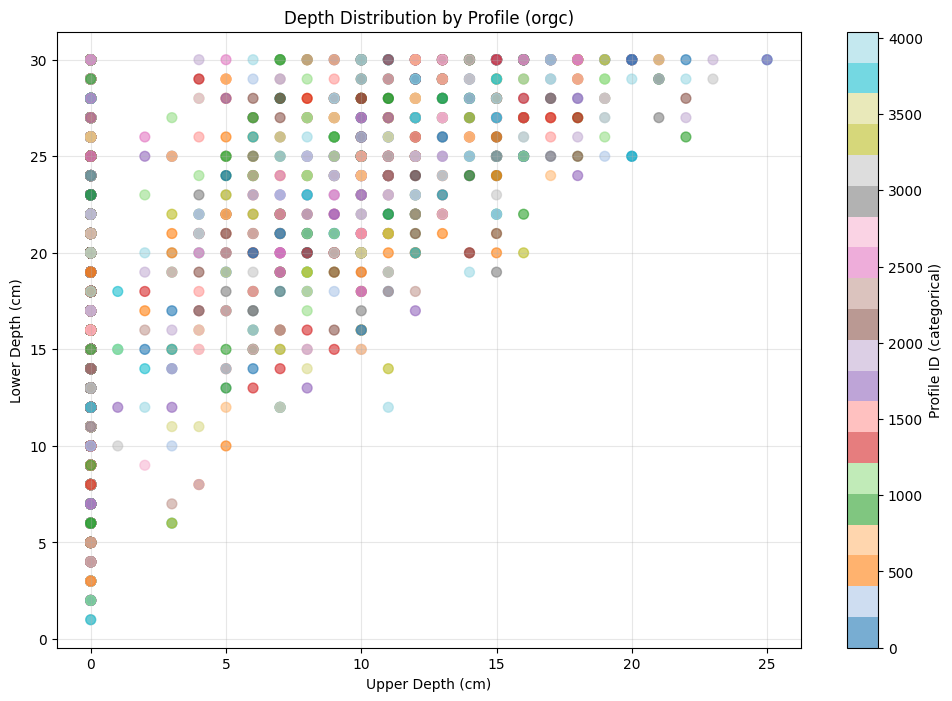

In [35]:
plot_scatter(orgc_df, title='Depth Distribution by Profile (orgc)')

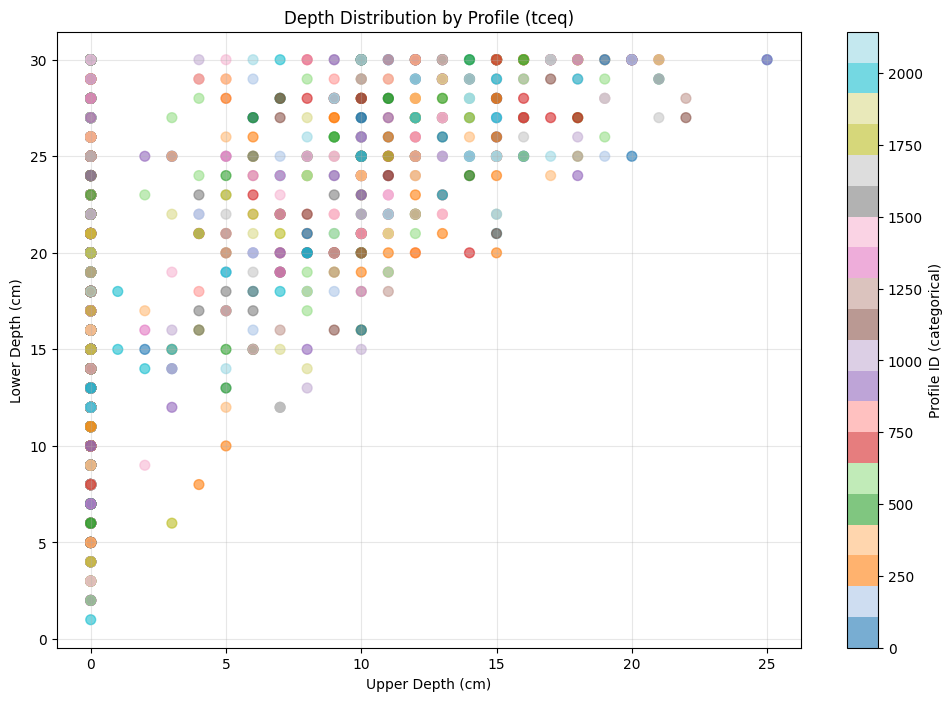

In [36]:
plot_scatter(tceq_df, title='Depth Distribution by Profile (tceq)')

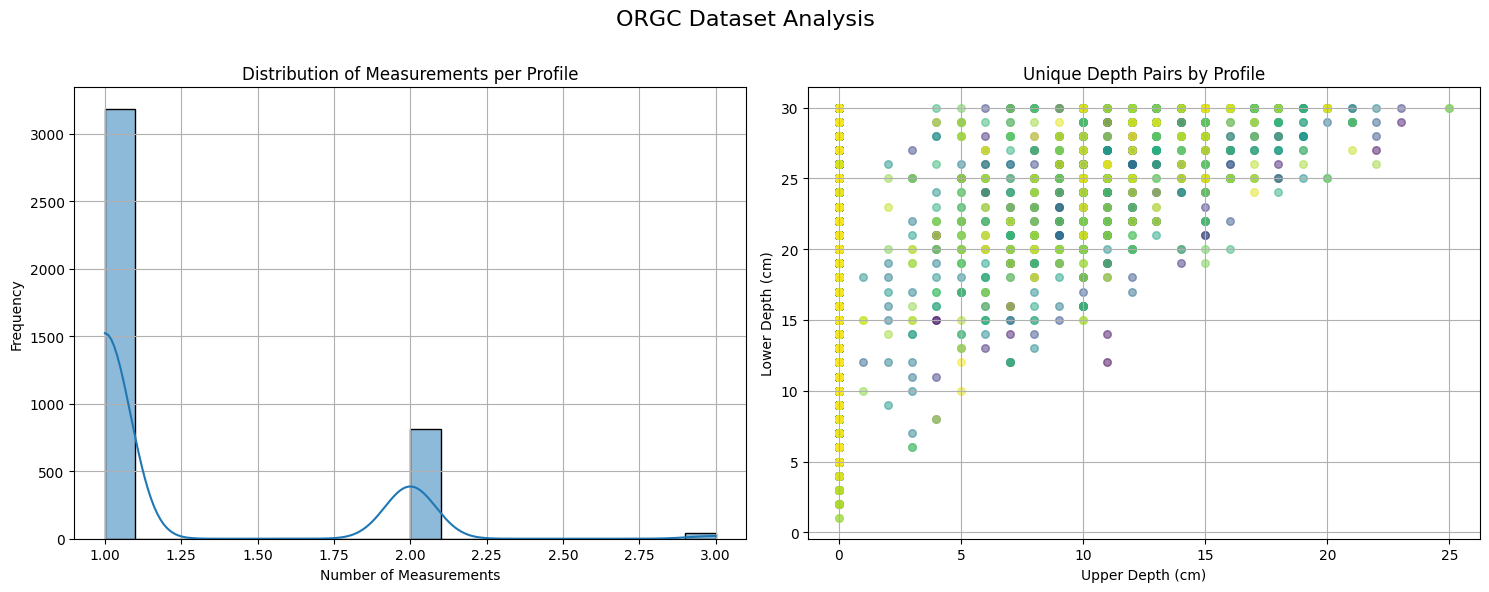

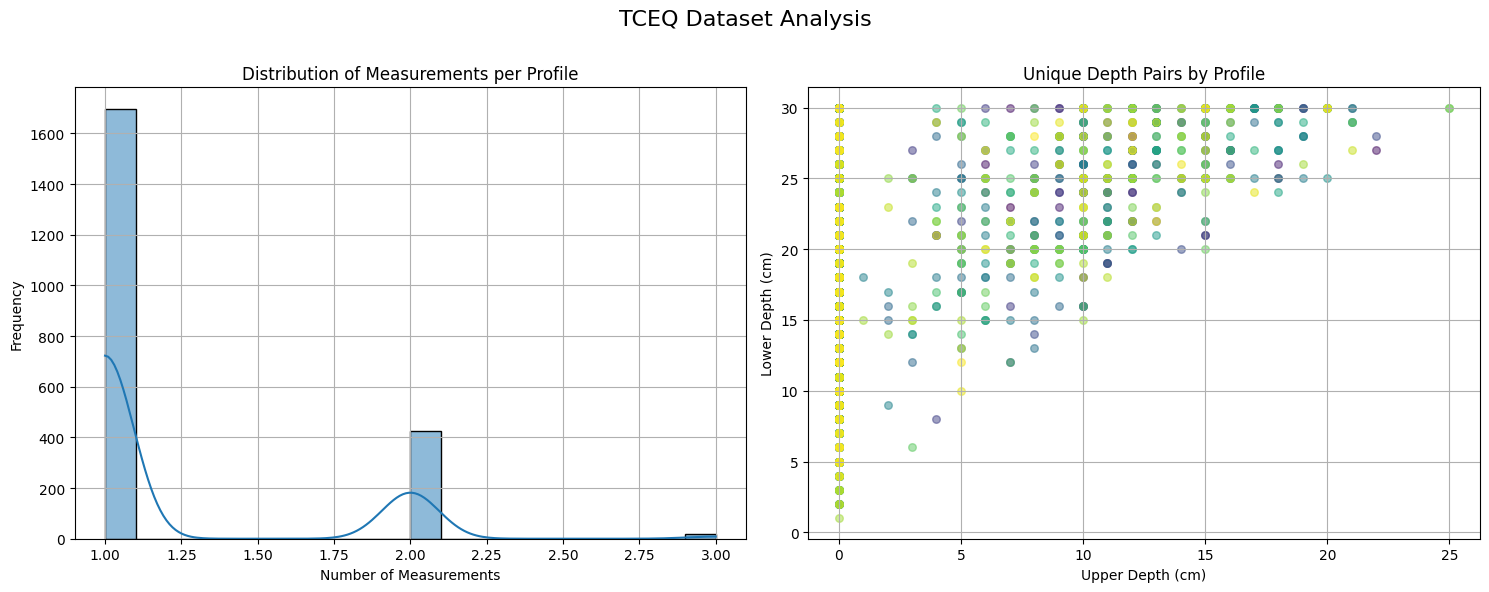

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def depth_analysis(df, title='Depth Analysis'):
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left plot: Distribution of number of measurements per profile
    depth_counts = df.groupby('profile_id').size()
    sns.histplot(depth_counts, bins=20, kde=True, ax=ax1)
    ax1.set_title('Distribution of Measurements per Profile')
    ax1.set_xlabel('Number of Measurements')
    ax1.set_ylabel('Frequency')
    ax1.grid(True)

    # Right plot: Unique depth pairs by profile
    profiles = df['profile_id'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(profiles)))
    
    for idx, profile in enumerate(profiles):
        profile_data = df[df['profile_id'] == profile]
        ax2.scatter(profile_data['upper_depth'], profile_data['lower_depth'], 
                   color=colors[idx], alpha=0.5, s=30)
    
    ax2.set_title('Unique Depth Pairs by Profile')
    ax2.set_xlabel('Upper Depth (cm)')
    ax2.set_ylabel('Lower Depth (cm)')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.suptitle(title, fontsize=16)
    plt.subplots_adjust(top=0.85)
    plt.show()

# Apply to both datasets
depth_analysis(orgc_df, "ORGC Dataset Analysis")
depth_analysis(tceq_df, "TCEQ Dataset Analysis")

In [38]:
def preprocessor_depth(df):
    # drop duplicates for same profile_id and depth
    df.drop_duplicates(subset=['profile_id', 'upper_depth', 'lower_depth'], inplace=True)
    logger.info(f"Number of records after dropping duplicates: {len(df)}")
    # check for missing values
    missing_values = df.isnull().sum()
    logger.info(f"Missing values in the dataset: {missing_values[missing_values > 0]}")
    # if there are missing values, drop them
    if missing_values.sum() > 0:
        df.dropna(inplace=True)
        logger.info(f"Number of records after dropping missing values: {len(df)}")
    
    # print final dataset info
    logger.info(f"Final number of records: {len(df)}")

    return df

In [39]:
orgc_df = preprocessor_depth(orgc_df)


INFO - Number of records after dropping duplicates: 4936
INFO - Missing values in the dataset: Series([], dtype: int64)
INFO - Final number of records: 4936


In [40]:
tceq_df = preprocessor_depth(tceq_df)

INFO - Number of records after dropping duplicates: 2612
INFO - Missing values in the dataset: Series([], dtype: int64)
INFO - Final number of records: 2612
